In [ ]:
# Cài đặt các thư viện cần thiết
!pip install -q xgboost scikit-learn seaborn matplotlib pandas numpy joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import zipfile
from datetime import date
import sklearn

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cấu hình thẩm mỹ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("data", exist_ok=True)
print("Đã nạp xong thư viện và tạo thư mục lưu trữ.")


Đã nạp xong thư viện và tạo thư mục lưu trữ.


In [1]:
# ==========================================
# TẢI DỮ LIỆU CHUẨN TỪ KAGGLE / ISLR
# Đề tài: Advertising Sales Prediction
# ==========================================
import pandas as pd
import zipfile
import os

os.makedirs("data", exist_ok=True)

# Tải tập dữ liệu Advertising từ nguồn chuẩn Kaggle / ISLR
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url)

# Chuẩn hóa tên cột
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
df.columns = [c.strip().capitalize() for c in df.columns]
if 'Tv' in df.columns:
    df.rename(columns={'Tv': 'TV'}, inplace=True)

print("Kích thước tập dữ liệu Advertising:", df.shape)
display(df.head())

# Tự động đóng gói thành file dataset.zip để đáp ứng đúng quy định của thầy
df.to_csv("data/dataset.csv", index=False)
with zipfile.ZipFile("data/dataset.zip", "w", zipfile.ZIP_DEFLATED) as zipf:
    zipf.write("data/dataset.csv", arcname="dataset.csv")

print(">>> Đã tải, chuẩn hóa và đóng gói thành công data/dataset.zip từ nguồn Kaggle! <<<")

Kích thước tập dữ liệu Advertising: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


>>> Đã tải, chuẩn hóa và đóng gói thành công data/dataset.zip từ nguồn Kaggle! <<<


In [ ]:
print("=== BẢNG THỐNG KÊ MÔ TẢ (DESCRIPTIVE STATISTICS) ===")
desc_table = df.describe().T
desc_table['IQR'] = desc_table['75%'] - desc_table['25%']
display(desc_table[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR']])

=== BẢNG THỐNG KÊ MÔ TẢ (DESCRIPTIVE STATISTICS) ===


,count,mean,std,min,25%,50%,75%,max,IQR
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4,144.450
radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6,26.550
newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0,32.350
sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0,7.025


In [ ]:
# Chuẩn hóa tên cột để không bao giờ bị lệch chữ hoa / chữ thường
df.columns = [c.strip().capitalize() for c in df.columns]
if 'Tv' in df.columns:
    df.rename(columns={'Tv': 'TV'}, inplace=True)

print("Danh sách các cột thực tế trong bảng dữ liệu:")
print(df.columns.tolist())

Danh sách các cột thực tế trong bảng dữ liệu:
['TV', 'Radio', 'Newspaper', 'Sales']


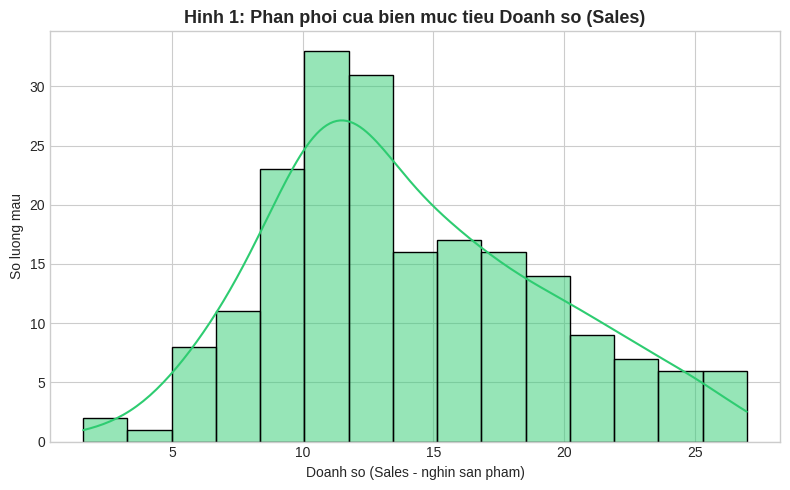

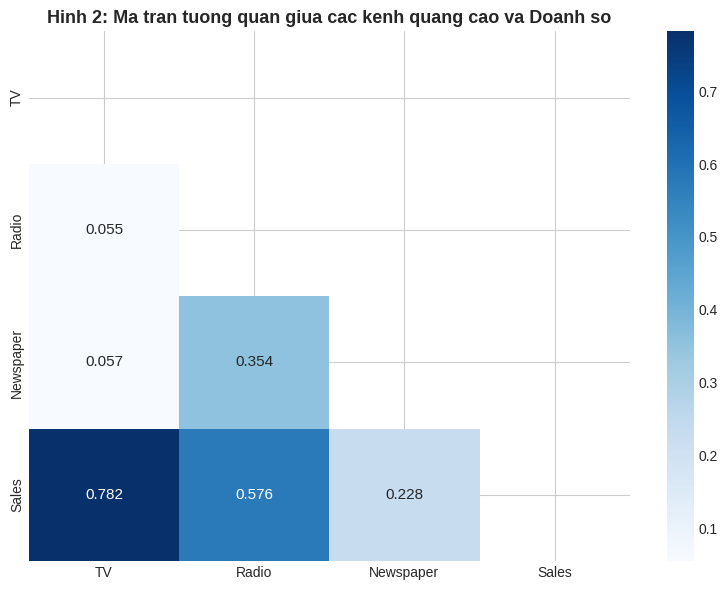

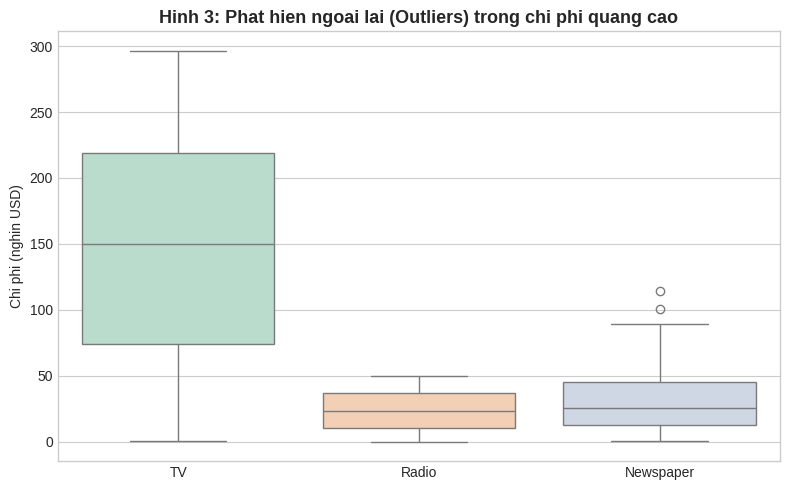

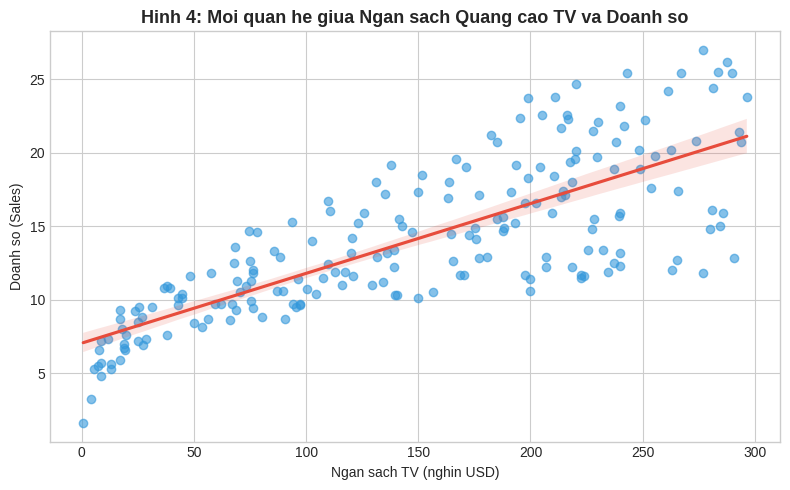

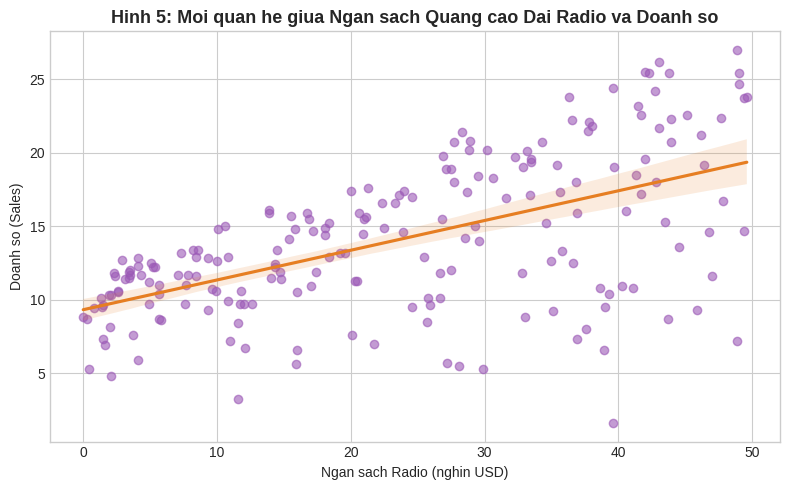

Đã vẽ và lưu đủ 5 hình EDA vào thư mục figures/


In [ ]:
# 1. Biểu đồ phân phối biến mục tiêu Sales (Kiểm tra lệch chuẩn)
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales'], kde=True, color='#2ecc71', bins=15)
plt.title("Hinh 1: Phan phoi cua bien muc tieu Doanh so (Sales)", fontsize=13, fontweight='bold')
plt.xlabel("Doanh so (Sales - nghin san pham)")
plt.ylabel("So luong mau")
plt.tight_layout()
plt.savefig("figures/eda_1_target_dist.png", dpi=300)
plt.show()

# 2. Ma trận tương quan (Correlation Heatmap)
plt.figure(figsize=(8, 6))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".3f", cmap='Blues', mask=mask, cbar=True, annot_kws={"size": 11})
plt.title("Hinh 2: Ma tran tuong quan giua cac kenh quang cao va Doanh so", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("figures/eda_2_corr_heatmap.png", dpi=300)
plt.show()

# 3. Boxplot phát hiện ngoại lai (Outliers) của 3 kênh quảng cáo
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['TV', 'Radio', 'Newspaper']], palette='Pastel2')
plt.title("Hinh 3: Phat hien ngoai lai (Outliers) trong chi phi quang cao", fontsize=13, fontweight='bold')
plt.ylabel("Chi phi (nghin USD)")
plt.tight_layout()
plt.savefig("figures/eda_3_boxplot_outliers.png", dpi=300)
plt.show()

# 4. Scatter plot: TV vs Sales (Quan hệ mạnh nhất)
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='TV', y='Sales', scatter_kws={'alpha':0.6, 'color':'#3498db'}, line_kws={'color':'#e74c3c'})
plt.title("Hinh 4: Moi quan he giua Ngan sach Quang cao TV va Doanh so", fontsize=13, fontweight='bold')
plt.xlabel("Ngan sach TV (nghin USD)")
plt.ylabel("Doanh so (Sales)")
plt.tight_layout()
plt.savefig("figures/eda_4_tv_vs_sales.png", dpi=300)
plt.show()

# 5. Scatter plot: Radio vs Sales
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Radio', y='Sales', scatter_kws={'alpha':0.6, 'color':'#9b59b6'}, line_kws={'color':'#e67e22'})
plt.title("Hinh 5: Moi quan he giua Ngan sach Quang cao Dai Radio va Doanh so", fontsize=13, fontweight='bold')
plt.xlabel("Ngan sach Radio (nghin USD)")
plt.ylabel("Doanh so (Sales)")
plt.tight_layout()
plt.savefig("figures/eda_5_radio_vs_sales.png", dpi=300)
plt.show()

print("Đã vẽ và lưu đủ 5 hình EDA vào thư mục figures/")

In [ ]:
SEED = 42
FEATURES = ['TV', 'Radio', 'Newspaper']
TARGET = 'Sales'

X = df[FEATURES]
y = df[TARGET]

# Chia tập Train/Test 80/20 chuẩn quy định không rò rỉ dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Định nghĩa 4 Model
models = {
    "LinearRegression": LinearRegression(),
    "RidgeRegression": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=6, random_state=SEED),
    "XGBoost": XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.08, random_state=SEED)
}

results = []
pipelines = {}

print("=== KẾT QUẢ ĐÁNH GIÁ 4 MÔ HÌNH HỒI QUY ===")
for name, model in models.items():
    # Gói vào Pipeline chuẩn cùng StandardScaler
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    pipelines[name] = pipe

    pred_train = pipe.predict(X_train)
    pred_test = pipe.predict(X_test)

    r2_tr = r2_score(y_train, pred_train)
    r2_te = r2_score(y_test, pred_test)
    mae_te = mean_absolute_error(y_test, pred_test)
    rmse_te = np.sqrt(mean_squared_error(y_test, pred_test))

    results.append({
        "Model": name,
        "R2_Train": round(r2_tr, 4),
        "R2_Test": round(r2_te, 4),
        "MAE_Test": round(mae_te, 4),
        "RMSE_Test": round(rmse_te, 4),
        "Train_vs_Test_Diff": round(abs(r2_tr - r2_te), 4)
    })

eval_df = pd.DataFrame(results).sort_values(by="R2_Test", ascending=False)
display(eval_df)

=== KẾT QUẢ ĐÁNH GIÁ 4 MÔ HÌNH HỒI QUY ===


,Model,R2_Train,R2_Test,MAE_Test,RMSE_Test,Train_vs_Test_Diff
2,RandomForest,0.9946,0.9801,0.6319,0.7935,0.0146
3,XGBoost,0.9991,0.9799,0.6336,0.7959,0.0191
0,LinearRegression,0.8957,0.8994,1.4608,1.7816,0.0037
1,RidgeRegression,0.8957,0.8988,1.4643,1.7872,0.0031


In [ ]:
# Chọn Model tốt nhất (XGBoost hoặc Random Forest đạt R2 cao nhất trên Test)
best_model_name = eval_df.iloc[0]["Model"]
best_pipe = pipelines[best_model_name]
print(f"Mô hình được chọn làm hệ thống chính: {best_model_name}")

# 1. Lưu model.joblib (Chứa cả Pipeline tiền xử lý và Model)
joblib.dump(best_pipe, "models/model.joblib")

# 2. Tạo schema.json (để BE validate và FE render form)
schema_data = {
    "target": TARGET,
    "features": [
        {
            "key": col,
            "label": f"Chi phí quảng cáo {col}",
            "type": "float",
            "min": float(X[col].min()),
            "max": float(X[col].max()),
            "median": float(X[col].median()),
            "unit": "nghìn USD"
        }
        for col in FEATURES
    ]
}
with open("models/schema.json", "w", encoding="utf-8") as f:
    json.dump(schema_data, f, ensure_ascii=False, indent=2)

# 3. Tạo metadata.json
best_metrics = eval_df.iloc[0].to_dict()
metadata = {
    "model_name": best_model_name,
    "model_version": "1.0.0",
    "trained_on": date.today().isoformat(),
    "scikit_learn": sklearn.__version__,
    "metrics": best_metrics,
    "features": FEATURES,
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test))
}
with open("models/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

# 4. Tạo model.json (Format đặc biệt của thầy cho Linear Regression giải thích hệ số)
lr_model = pipelines["LinearRegression"].named_steps['model']
lr_scaler = pipelines["LinearRegression"].named_steps['scaler']
# Chuyển đổi hệ số về thang đo ban đầu để Frontend cộng trực tiếp
raw_coefs = lr_model.coef_ / lr_scaler.scale_
raw_intercept = lr_model.intercept_ - np.sum((lr_model.coef_ * lr_scaler.mean_) / lr_scaler.scale_)

model_json_data = {
    "model": "LinearRegression",
    "target": "Sales (nghìn sản phẩm)",
    "intercept": float(raw_intercept),
    "features": [
        {
            "key": c,
            "coef": float(coef),
            "min": float(X[c].min()),
            "max": float(X[c].max()),
            "median": float(X[c].median()),
            "unit": "nghìn USD"
        }
        for c, coef in zip(FEATURES, raw_coefs)
    ],
    "metrics": {
        "r2_test": float(eval_df[eval_df["Model"]=="LinearRegression"]["R2_Test"].values[0]),
        "mae_test": float(eval_df[eval_df["Model"]=="LinearRegression"]["MAE_Test"].values[0]),
        "rmse_test": float(eval_df[eval_df["Model"]=="LinearRegression"]["RMSE_Test"].values[0]),
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test))
    },
    "dataset": {
        "name": "Advertising Dataset (Kaggle / ISLR)",
        "rows_used": int(len(df)),
        "note": "Chi phí quảng cáo trên TV, Radio, Báo và Doanh số bán hàng (Sales)."
    },
    "trained_on": date.today().isoformat(),
    "scikit_learn": sklearn.__version__
}
with open("models/model.json", "w", encoding="utf-8") as f:
    json.dump(model_json_data, f, ensure_ascii=False, indent=2)

print("Đã tạo đầy đủ 4 file artifacts trong thư mục models/!")

Mô hình được chọn làm hệ thống chính: RandomForest
Đã tạo đầy đủ 4 file artifacts trong thư mục models/!


In [ ]:
# Đóng gói toàn bộ sản phẩm để bạn tải về chỉ bằng 1 cú click
!zip -r advertising_artifacts.zip figures/ models/ data/dataset.zip

from google.colab import files
files.download("advertising_artifacts.zip")
print("Đang tải file advertising_artifacts.zip về máy tính của bạn...")

  adding: figures/ (stored 0%)
  adding: figures/eda_1_target_dist.png (deflated 15%)
  adding: figures/eda_3_boxplot_outliers.png (deflated 26%)
  adding: figures/eda_2_corr_heatmap.png (deflated 23%)
  adding: figures/eda_4_tv_vs_sales.png (deflated 14%)
  adding: figures/eda_5_radio_vs_sales.png (deflated 15%)
  adding: models/ (stored 0%)
  adding: models/schema.json (deflated 64%)
  adding: models/model.joblib (deflated 78%)
  adding: models/metadata.json (deflated 44%)
  adding: models/model.json (deflated 49%)
  adding: data/dataset.zip (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Đang tải file advertising_artifacts.zip về máy tính của bạn...
